In [1]:
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

from carvana.dataset.dataset import CarvanaDataset, dataset_info
from carvana.dataset.utils import check_dataset_integrity
from carvana.config import *
from carvana.dataset.utils import calculate_mask_statistics

/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## Общая информация о датасете

In [3]:
image_files, mask_files = dataset_info(str(TRAIN_IMAGES_DIR), str(TRAIN_MASKS_DIR), str(TRAIN_MASKS_CSV))

Количество изображений: 5088
Количество масок: 5088
Соответствующих пар (пример из 10): 10/10
Размер изображений: (1918, 1280)
Записей в CSV: 5088


In [4]:
integrity_info = check_dataset_integrity(str(TRAIN_IMAGES_DIR), str(TRAIN_MASKS_DIR))
print(f"Всего изображений: {integrity_info['total_images']}")
print(f"Всего масок: {integrity_info['total_masks']}")
print(f"Пропущенных масок: {len(integrity_info['missing_masks'])}")
print(f"Пропущенных изображений: {len(integrity_info['missing_images'])}")

Всего изображений: 5088
Всего масок: 5088
Пропущенных масок: 0
Пропущенных изображений: 0


In [5]:
dataset = CarvanaDataset(
    images_dir=str(TRAIN_IMAGES_DIR),
    masks_dir=str(TRAIN_MASKS_DIR),
    csv_file=str(TRAIN_MASKS_CSV)
)

print(f"Размер датасета: {len(dataset)} изображений")

Размер датасета: 5088 изображений


In [38]:
mask_stats = calculate_mask_statistics(dataset, num_samples=min(50, len(dataset)))
for key, value in mask_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value:,}")

  foreground_pixels: 27,306,923
  total_pixels: 122,752,000
  foreground_ratio: 0.2225
  background_ratio: 0.7775


## Визуализация образцов

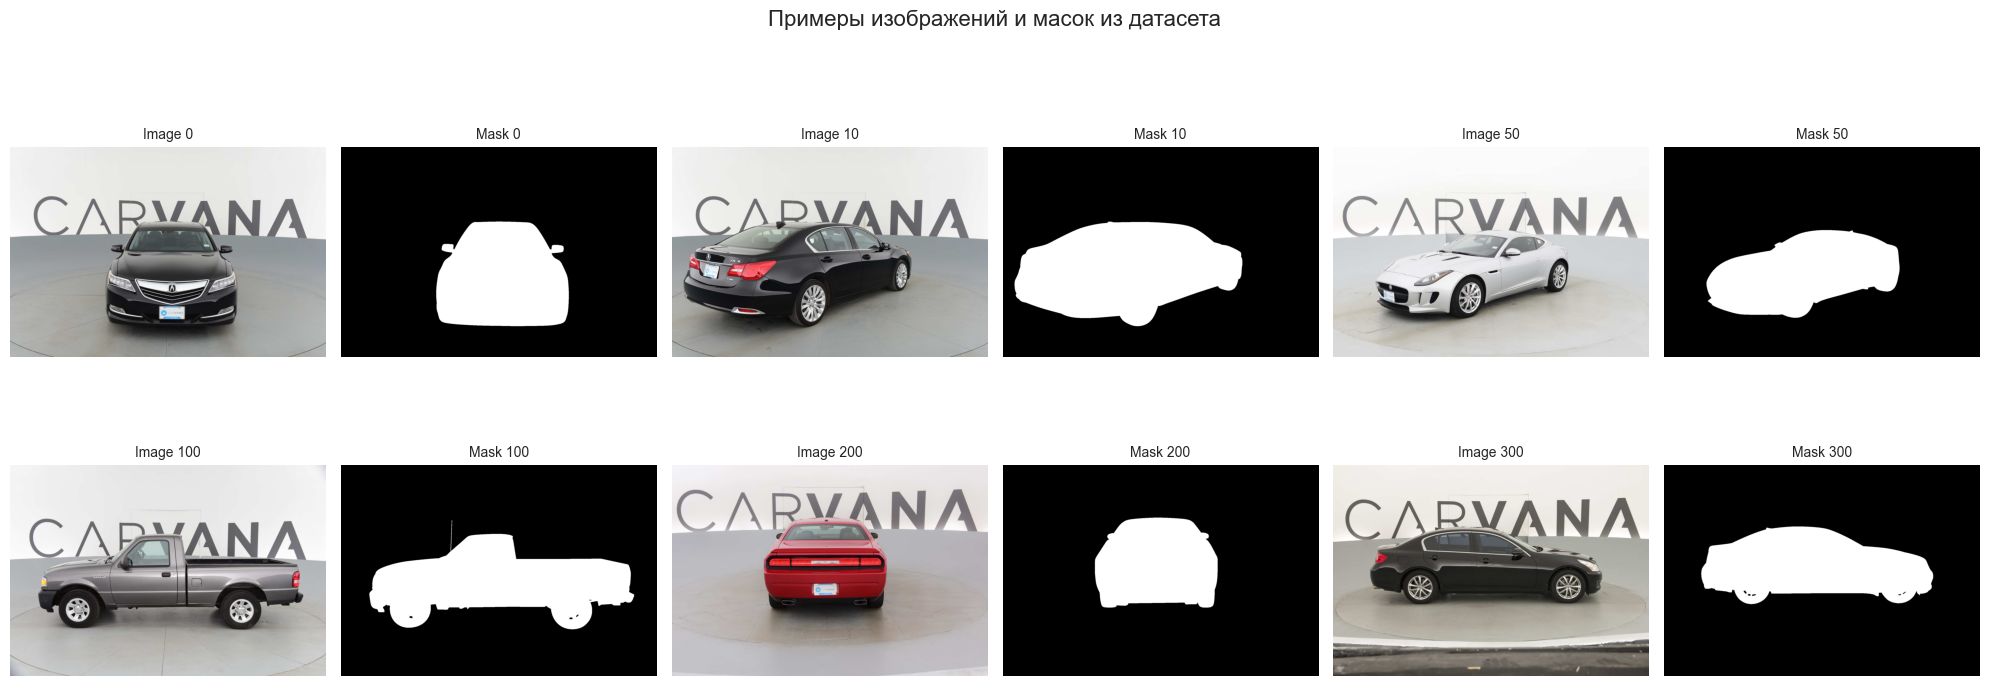

In [40]:
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
axes = axes.ravel()

indices_to_show = [0, 10, 50, 100, 200, 300][:min(6, len(dataset))]

for i, idx in enumerate(indices_to_show):
    if i >= 6:
        break

    try:
        image, mask = dataset[idx]

        image_np = image.permute(1, 2, 0).numpy().astype(np.uint8)
        mask_np = mask.squeeze().numpy()

        axes[i*2].imshow(image_np)
        axes[i*2].set_title(f'Image {idx}', fontsize=10)
        axes[i*2].axis('off')

        axes[i*2 + 1].imshow(mask_np, cmap='gray')
        axes[i*2 + 1].set_title(f'Mask {idx}', fontsize=10)
        axes[i*2 + 1].axis('off')

    except Exception as e:
        axes[i*2].text(0.5, 0.5, f'Error\nImage {idx}\n{str(e)[:20]}...', ha='center', va='center', fontsize=8)
        axes[i*2].axis('off')
        axes[i*2 + 1].axis('off')

plt.suptitle('Примеры изображений и масок из датасета', fontsize=16)
plt.tight_layout()
plt.show()


## Анализ масок

In [7]:
mask_areas = []
aspect_ratios = []
mask_centers_x = []
mask_centers_y = []

for i in range(0, min(100, len(dataset)), 5):
    try:
        _, mask = dataset[i]
        mask_np = mask.squeeze().numpy()

        area = np.sum(mask_np > 0.5)
        mask_areas.append(area)

        rows, cols = np.where(mask_np > 0.5)
        if len(rows) > 0:
            height = np.max(rows) - np.min(rows)
            width = np.max(cols) - np.min(cols)
            if width > 0:
                aspect_ratios.append(height / width)

            center_y = np.mean(rows)
            center_x = np.mean(cols)
            mask_centers_x.append(center_x)
            mask_centers_y.append(center_y)
    except Exception as e:
        continue

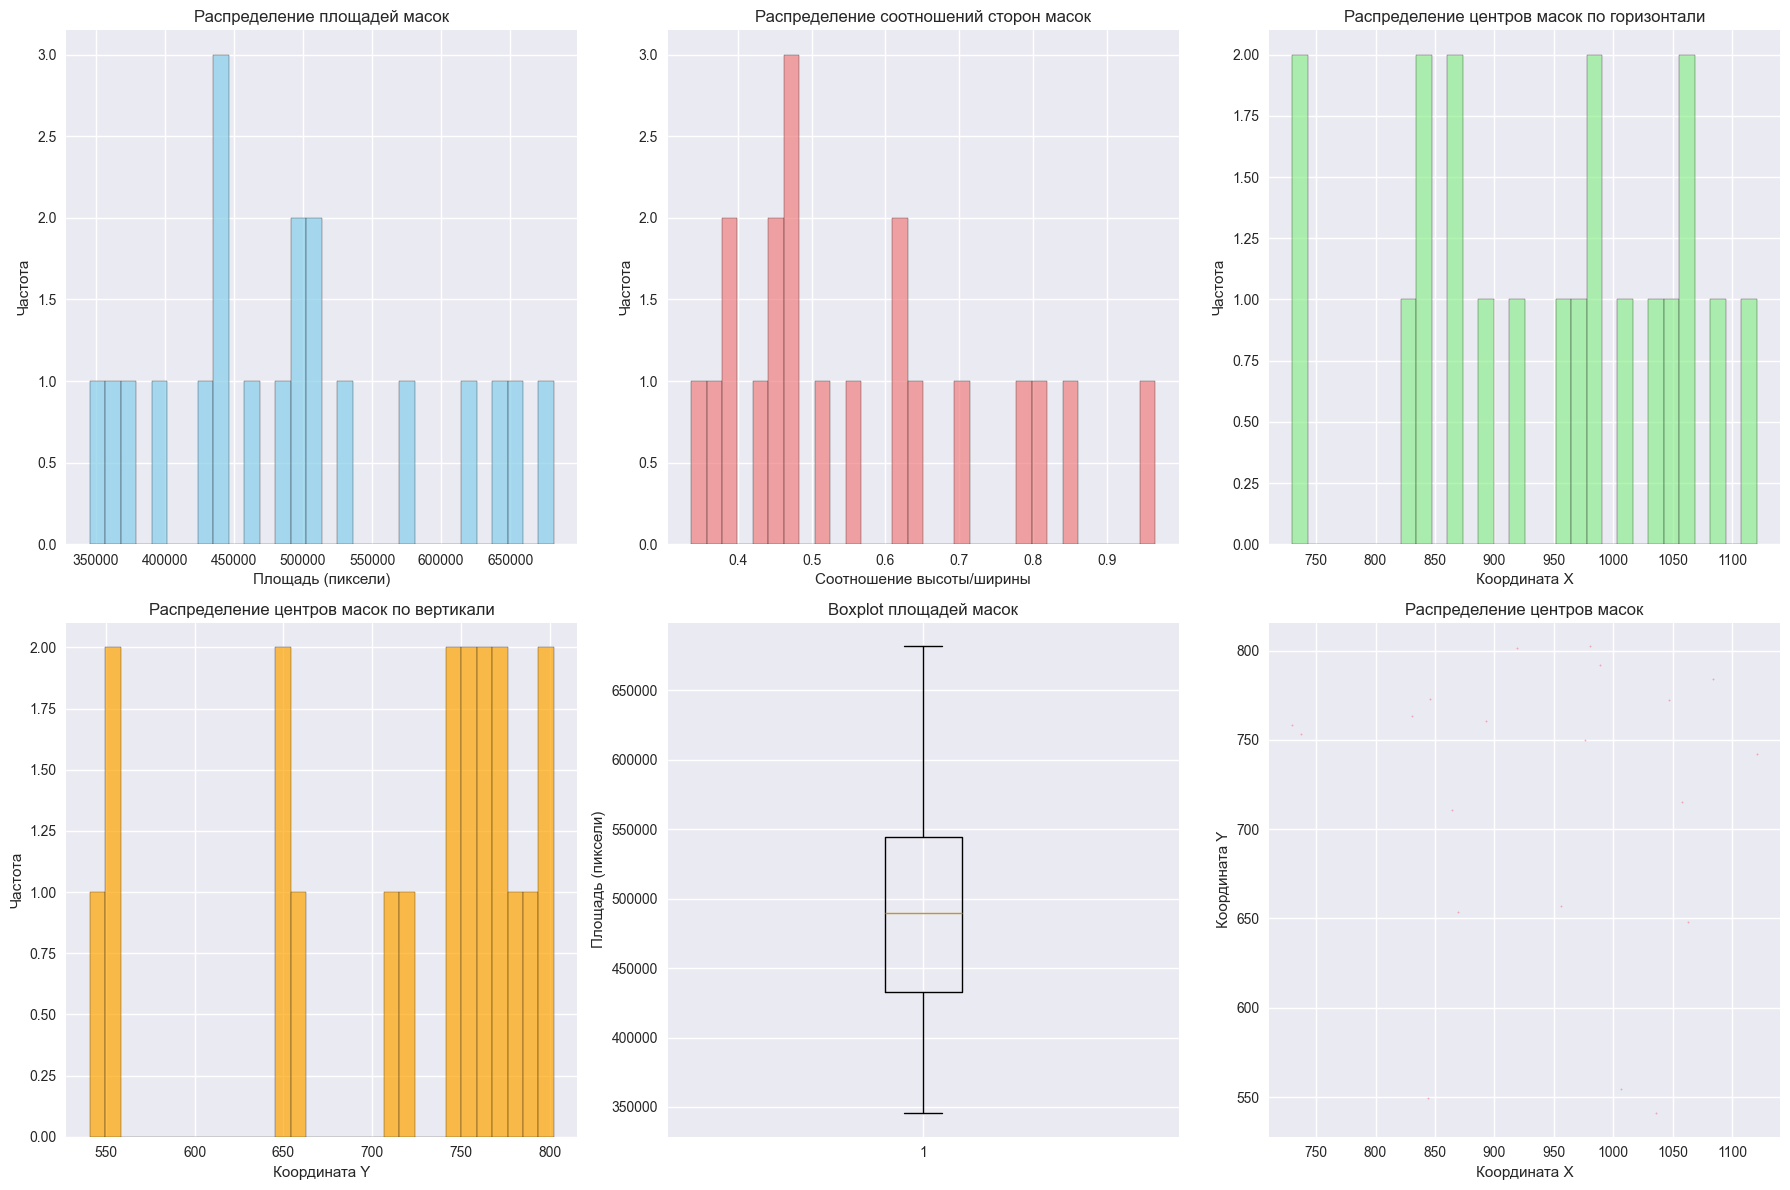

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].hist(mask_areas, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Распределение площадей масок')
axes[0, 0].set_xlabel('Площадь (пиксели)')
axes[0, 0].set_ylabel('Частота')

axes[0, 1].hist(aspect_ratios, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Распределение соотношений сторон масок')
axes[0, 1].set_xlabel('Соотношение высоты/ширины')
axes[0, 1].set_ylabel('Частота')

axes[0, 2].hist(mask_centers_x, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Распределение центров масок по горизонтали')
axes[0, 2].set_xlabel('Координата X')
axes[0, 2].set_ylabel('Частота')

axes[1, 0].hist(mask_centers_y, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_title('Распределение центров масок по вертикали')
axes[1, 0].set_xlabel('Координата Y')
axes[1, 0].set_ylabel('Частота')

axes[1, 1].boxplot(mask_areas, vert=True)
axes[1, 1].set_title('Boxplot площадей масок')
axes[1, 1].set_ylabel('Площадь (пиксели)')

axes[1, 2].scatter(mask_centers_x, mask_centers_y, alpha=0.5, s=1)
axes[1, 2].set_title('Распределение центров масок')
axes[1, 2].set_xlabel('Координата X')
axes[1, 2].set_ylabel('Координата Y')

plt.tight_layout()
plt.show()

In [9]:
print(f"Средняя площадь маски: {np.mean(mask_areas):.0f} пикселей")
print(f"Медианная площадь маски: {np.median(mask_areas):.0f} пикселей")
print(f"Стандартное отклонение площади: {np.std(mask_areas):.0f} пикселей")
print(f"Минимальная площадь: {np.min(mask_areas):.0f} пикселей")
print(f"Максимальная площадь: {np.max(mask_areas):.0f} пикселей")

print(f"\nСреднее соотношение сторон: {np.mean(aspect_ratios):.2f}")
print(f"Медианное соотношение сторон: {np.median(aspect_ratios):.2f}")

Средняя площадь маски: 494626 пикселей
Медианная площадь маски: 489389 пикселей
Стандартное отклонение площади: 95533 пикселей
Минимальная площадь: 345418 пикселей
Максимальная площадь: 681673 пикселей

Среднее соотношение сторон: 0.57
Медианное соотношение сторон: 0.50


## Цветовые характеристики изображений

In [10]:
red_means, green_means, blue_means = [], [], []
red_stds, green_stds, blue_stds = [], [], []
brightness_means = []

sample_size = min(50, len(dataset))

for i in range(0, len(dataset), max(1, len(dataset)//sample_size)):
    try:
        image, _ = dataset[i]
        image_np = image.permute(1, 2, 0).numpy().astype(np.uint8)

        red_channel = image_np[:, :, 0]
        green_channel = image_np[:, :, 1]
        blue_channel = image_np[:, :, 2]

        red_means.append(np.mean(red_channel))
        green_means.append(np.mean(green_channel))
        blue_means.append(np.mean(blue_channel))

        red_stds.append(np.std(red_channel))
        green_stds.append(np.std(green_channel))
        blue_stds.append(np.std(blue_channel))

        brightness = np.mean(image_np, axis=2)
        brightness_means.append(np.mean(brightness))

    except Exception as e:
        continue

Анализ 50 изображений...


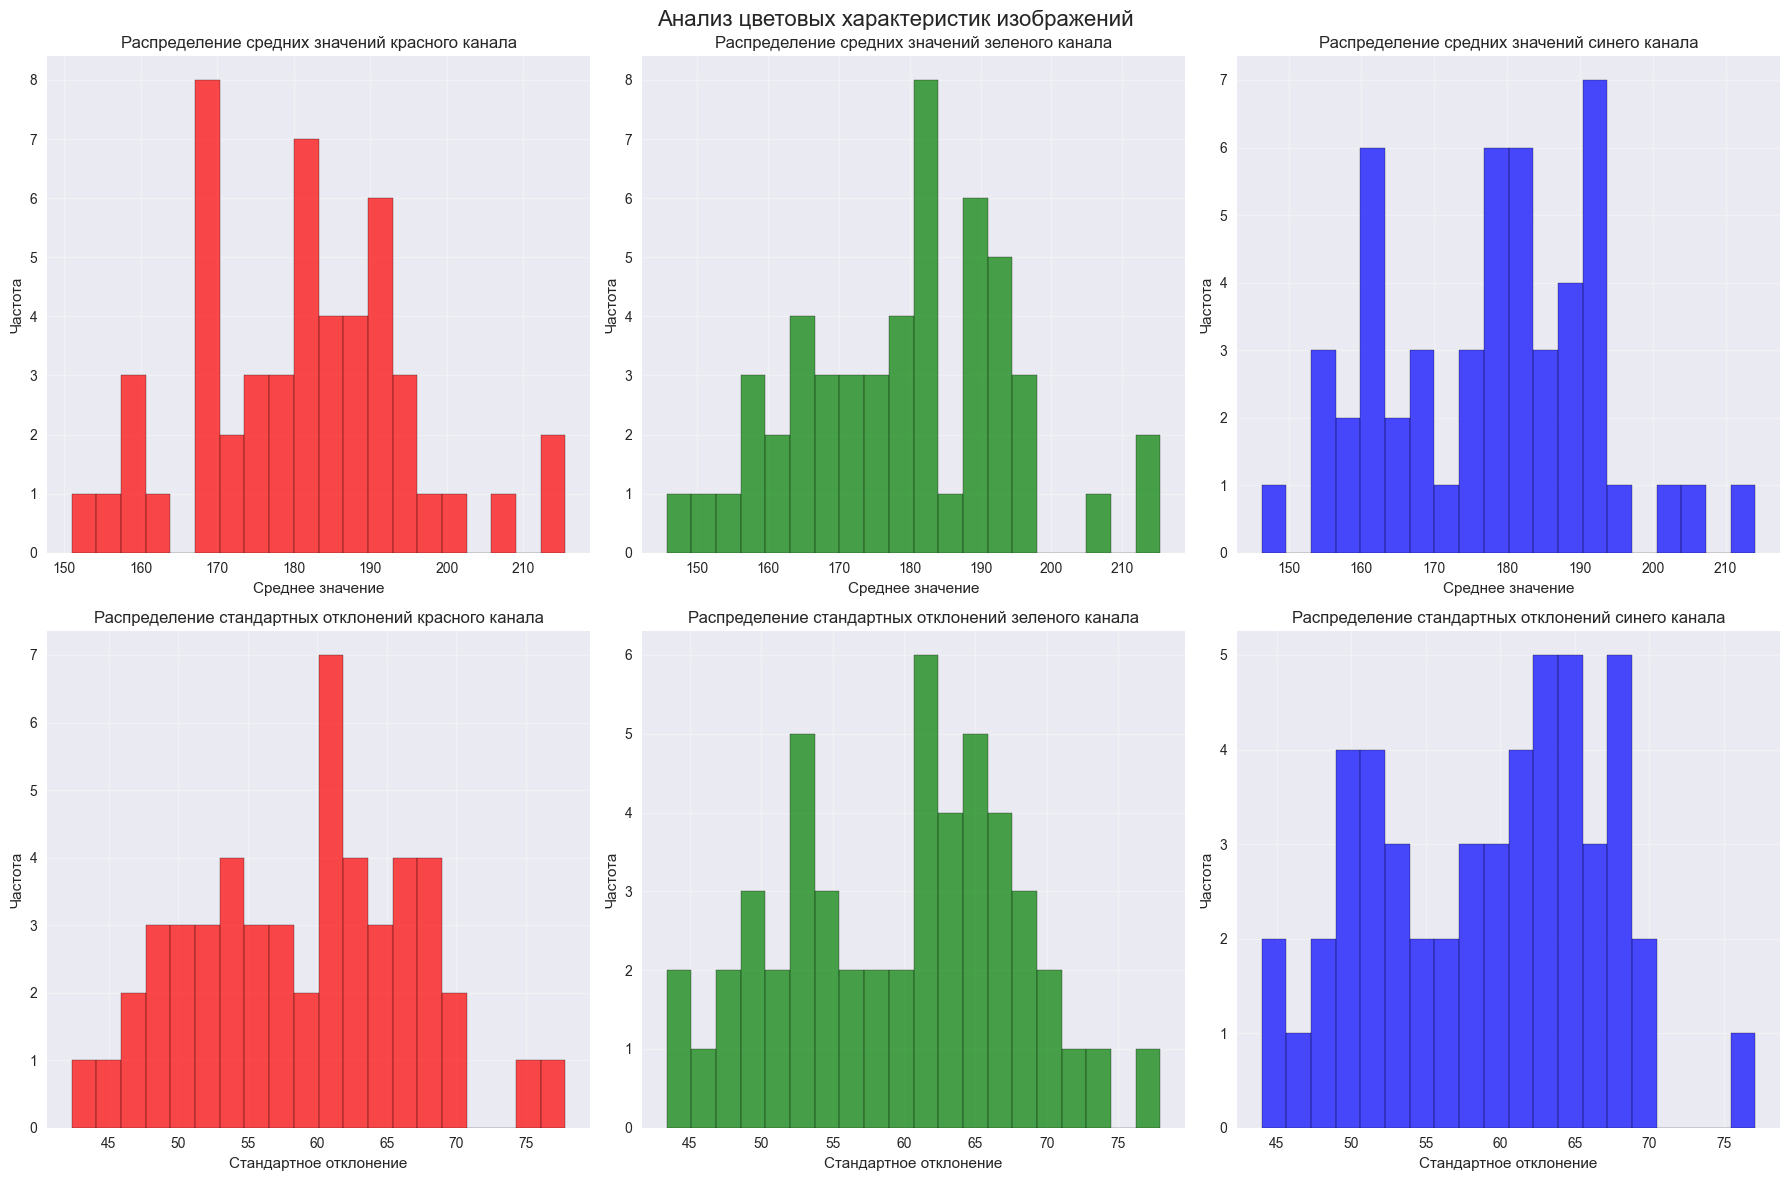

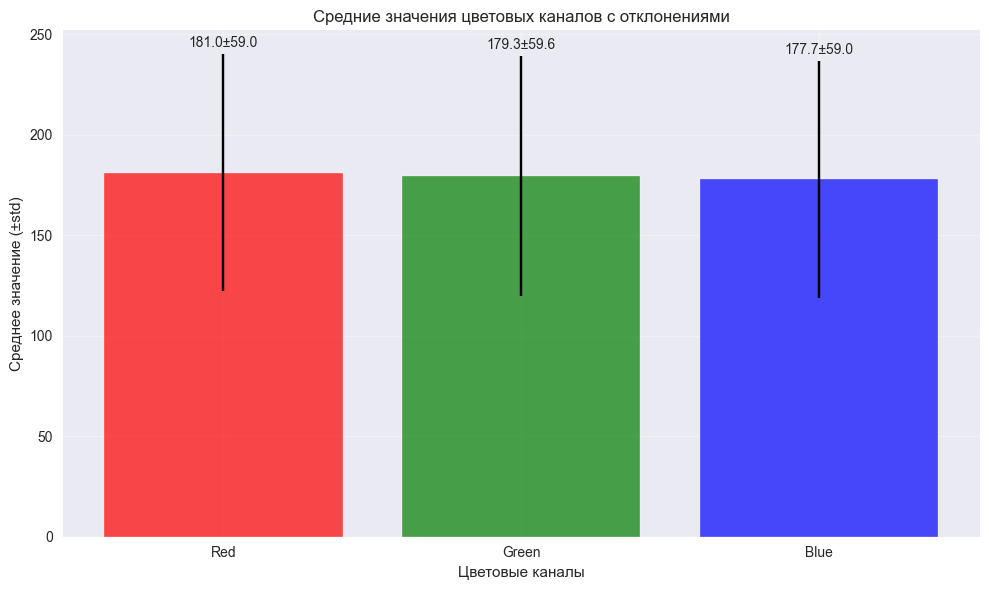

ЦВЕТОВАЯ СТАТИСТИКА:
Красный канал: среднее = 180.96, std = 58.96
Зеленый канал: среднее = 179.33, std = 59.62
Синий канал: среднее = 177.75, std = 58.99
Общая яркость: среднее = 179.34, std = 14.22


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].hist(red_means, bins=20, alpha=0.7, color='red', label='Red', edgecolor='black')
axes[0, 0].set_title('Распределение средних значений красного канала')
axes[0, 0].set_xlabel('Среднее значение')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(green_means, bins=20, alpha=0.7, color='green', label='Green', edgecolor='black')
axes[0, 1].set_title('Распределение средних значений зеленого канала')
axes[0, 1].set_xlabel('Среднее значение')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(blue_means, bins=20, alpha=0.7, color='blue', label='Blue', edgecolor='black')
axes[0, 2].set_title('Распределение средних значений синего канала')
axes[0, 2].set_xlabel('Среднее значение')
axes[0, 2].set_ylabel('Частота')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].hist(red_stds, bins=20, alpha=0.7, color='red', label='Red STD', edgecolor='black')
axes[1, 0].set_title('Распределение стандартных отклонений красного канала')
axes[1, 0].set_xlabel('Стандартное отклонение')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(green_stds, bins=20, alpha=0.7, color='green', label='Green STD', edgecolor='black')
axes[1, 1].set_title('Распределение стандартных отклонений зеленого канала')
axes[1, 1].set_xlabel('Стандартное отклонение')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(blue_stds, bins=20, alpha=0.7, color='blue', label='Blue STD', edgecolor='black')
axes[1, 2].set_title('Распределение стандартных отклонений синего канала')
axes[1, 2].set_xlabel('Стандартное отклонение')
axes[1, 2].set_ylabel('Частота')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Анализ цветовых характеристик изображений', fontsize=16)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
channels = ['Red', 'Green', 'Blue']
means = [np.mean(red_means), np.mean(green_means), np.mean(blue_means)]
stds = [np.mean(red_stds), np.mean(green_stds), np.mean(blue_stds)]

x_pos = np.arange(len(channels))
ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color=['red', 'green', 'blue'])
ax.set_xlabel('Цветовые каналы')
ax.set_ylabel('Среднее значение (±std)')
ax.set_title('Средние значения цветовых каналов с отклонениями')
ax.set_xticks(x_pos)
ax.set_xticklabels(channels)
ax.grid(True, alpha=0.3)

for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 2, f'{mean:.1f}±{std:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"ЦВЕТОВАЯ СТАТИСТИКА:")
print(f"Красный канал: среднее = {np.mean(red_means):.2f}, std = {np.mean(red_stds):.2f}")
print(f"Зеленый канал: среднее = {np.mean(green_means):.2f}, std = {np.mean(green_stds):.2f}")
print(f"Синий канал: среднее = {np.mean(blue_means):.2f}, std = {np.mean(blue_stds):.2f}")
print(f"Общая яркость: среднее = {np.mean(brightness_means):.2f}, std = {np.std(brightness_means):.2f}")


## Анализ текстур и контрастности

In [12]:
def compute_gradient_magnitude(image_np):
    """Вычисляет магнитуду градиента изображения"""
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return gradient_magnitude

In [13]:
def compute_local_contrast(image_np, window_size=15):
    """Вычисляет локальную контрастность изображения"""
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    mean_filtered = cv2.boxFilter(gray, -1, (window_size, window_size))
    contrast = np.abs(gray.astype(np.float32) - mean_filtered.astype(np.float32))
    return contrast

In [14]:
gradient_means, contrast_means = [], []
edge_densities = []
texture_homogeneity = []

sample_indices = np.random.choice(len(dataset), min(30, len(dataset)), replace=False)

for idx in sample_indices:
    try:
        image, mask = dataset[idx]
        image_np = image.permute(1, 2, 0).numpy().astype(np.uint8)
        mask_np = mask.squeeze().numpy()

        gradient_mag = compute_gradient_magnitude(image_np)
        gradient_means.append(np.mean(gradient_mag))

        local_contrast = compute_local_contrast(image_np)
        contrast_means.append(np.mean(local_contrast))

        edges = cv2.Canny(image_np, 50, 150)
        edge_density = np.sum(edges > 0) / edges.size
        edge_densities.append(edge_density)

        texture_homo = 1 / (1 + np.mean(gradient_mag))
        texture_homogeneity.append(texture_homo)

    except Exception as e:
        continue

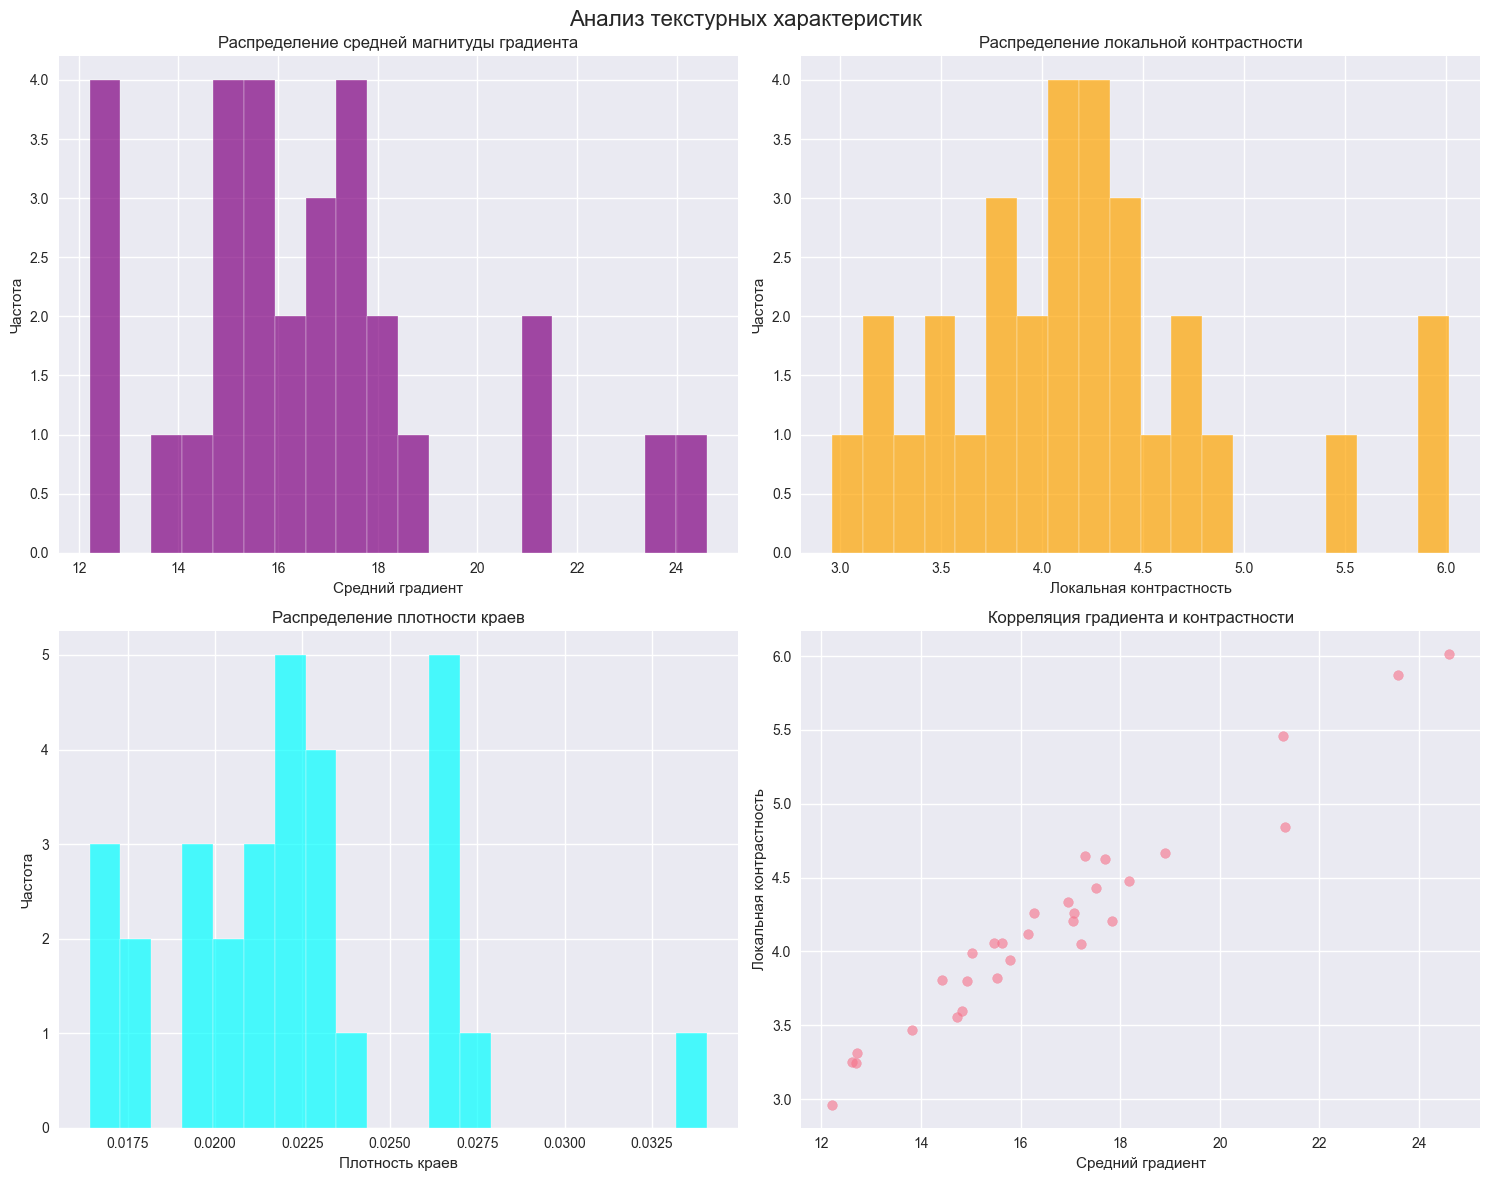

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].hist(gradient_means, bins=20, alpha=0.7, color='purple')
axes[0, 0].set_title('Распределение средней магнитуды градиента')
axes[0, 0].set_xlabel('Средний градиент')
axes[0, 0].set_ylabel('Частота')

axes[0, 1].hist(contrast_means, bins=20, alpha=0.7, color='orange')
axes[0, 1].set_title('Распределение локальной контрастности')
axes[0, 1].set_xlabel('Локальная контрастность')
axes[0, 1].set_ylabel('Частота')

axes[1, 0].hist(edge_densities, bins=20, alpha=0.7, color='cyan')
axes[1, 0].set_title('Распределение плотности краев')
axes[1, 0].set_xlabel('Плотность краев')
axes[1, 0].set_ylabel('Частота')

axes[1, 1].scatter(gradient_means, contrast_means, alpha=0.6)
axes[1, 1].set_title('Корреляция градиента и контрастности')
axes[1, 1].set_xlabel('Средний градиент')
axes[1, 1].set_ylabel('Локальная контрастность')

plt.suptitle('Анализ текстурных характеристик', fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
print(f"Средний градиент: {np.mean(gradient_means):.2f}")
print(f"Стандартное отклонение градиента: {np.std(gradient_means):.2f}")
print(f"Средняя контрастность: {np.mean(contrast_means):.2f}")
print(f"Средняя плотность краев: {np.mean(edge_densities)*100:.2f}%")

Средний градиент: 16.64
Стандартное отклонение градиента: 2.96
Средняя контрастность: 4.18
Средняя плотность краев: 2.24%


## Пространственное расположение автомобилей

In [17]:
car_positions_x = []
car_positions_y = []
bounding_boxes = []
car_sizes = []

for i in range(0, min(100, len(dataset))):
    try:
        _, mask = dataset[i]
        mask_np = mask.squeeze().numpy()

        rows, cols = np.where(mask_np > 0.5)

        if len(rows) > 0:
            center_y = np.mean(rows)
            center_x = np.mean(cols)
            car_positions_x.append(center_x / mask_np.shape[1])
            car_positions_y.append(center_y / mask_np.shape[0])

            min_row, max_row = np.min(rows), np.max(rows)
            min_col, max_col = np.min(cols), np.max(cols)
            bbox_width = max_col - min_col
            bbox_height = max_row - min_row
            bounding_boxes.append((bbox_width, bbox_height))

            relative_size = (bbox_width * bbox_height) / (mask_np.shape[0] * mask_np.shape[1])
            car_sizes.append(relative_size)

    except Exception as e:
        continue

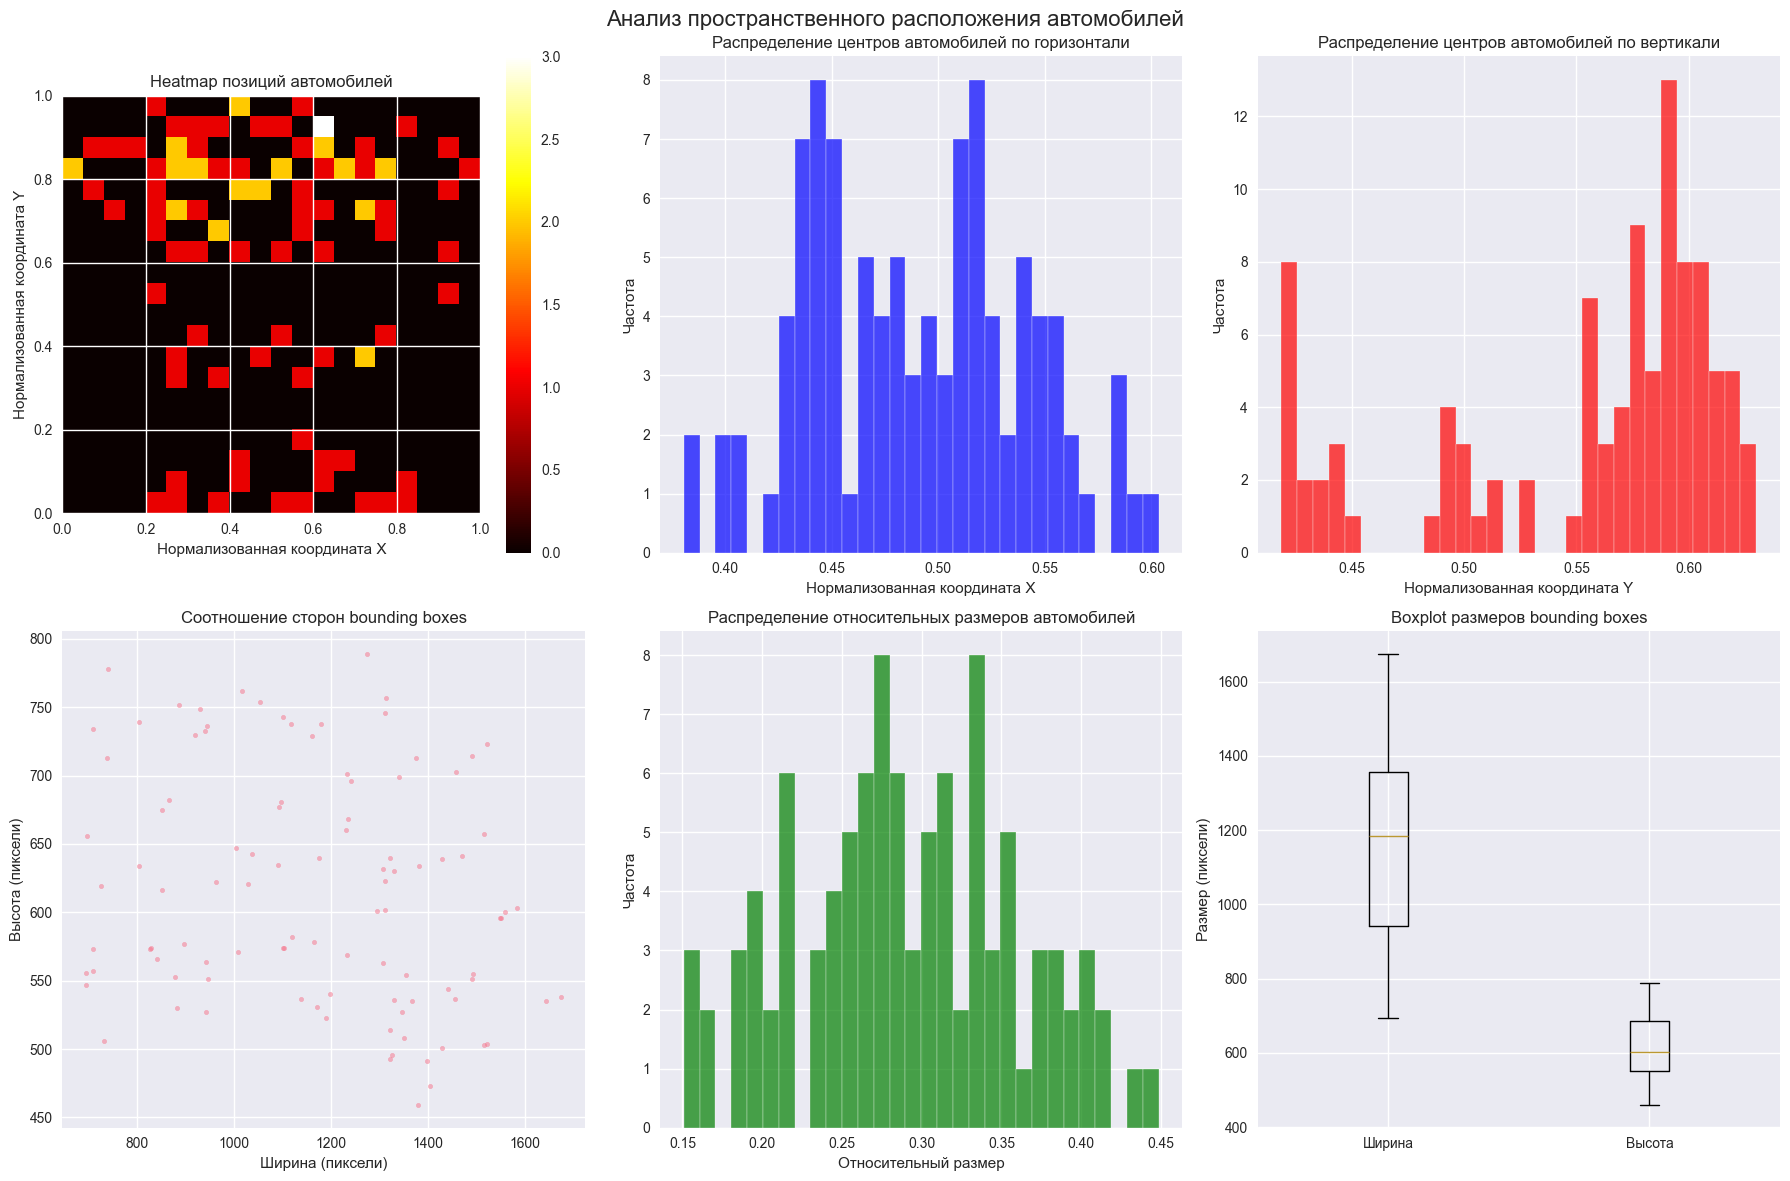

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

heatmap, xedges, yedges = np.histogram2d(car_positions_x, car_positions_y, bins=20)
im = axes[0, 0].imshow(heatmap.T, origin='lower', cmap='hot', extent=[0, 1, 0, 1])
axes[0, 0].set_title('Heatmap позиций автомобилей')
axes[0, 0].set_xlabel('Нормализованная координата X')
axes[0, 0].set_ylabel('Нормализованная координата Y')
plt.colorbar(im, ax=axes[0, 0])

axes[0, 1].hist(car_positions_x, bins=30, alpha=0.7, color='blue')
axes[0, 1].set_title('Распределение центров автомобилей по горизонтали')
axes[0, 1].set_xlabel('Нормализованная координата X')
axes[0, 1].set_ylabel('Частота')

axes[0, 2].hist(car_positions_y, bins=30, alpha=0.7, color='red')
axes[0, 2].set_title('Распределение центров автомобилей по вертикали')
axes[0, 2].set_xlabel('Нормализованная координата Y')
axes[0, 2].set_ylabel('Частота')

bbox_widths = [bbox[0] for bbox in bounding_boxes]
bbox_heights = [bbox[1] for bbox in bounding_boxes]
axes[1, 0].scatter(bbox_widths, bbox_heights, alpha=0.5, s=10)
axes[1, 0].set_title('Соотношение сторон bounding boxes')
axes[1, 0].set_xlabel('Ширина (пиксели)')
axes[1, 0].set_ylabel('Высота (пиксели)')

axes[1, 1].hist(car_sizes, bins=30, alpha=0.7, color='green')
axes[1, 1].set_title('Распределение относительных размеров автомобилей')
axes[1, 1].set_xlabel('Относительный размер')
axes[1, 1].set_ylabel('Частота')

axes[1, 2].boxplot([bbox_widths, bbox_heights], labels=['Ширина', 'Высота'])
axes[1, 2].set_title('Boxplot размеров bounding boxes')
axes[1, 2].set_ylabel('Размер (пиксели)')

plt.suptitle('Анализ пространственного расположения автомобилей', fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
print(f"Средняя позиция по X: {np.mean(car_positions_x):.3f}")
print(f"Стандартное отклонение по X: {np.std(car_positions_x):.3f}")
print(f"Средняя позиция по Y: {np.mean(car_positions_y):.3f}")
print(f"Стандартное отклонение по Y: {np.std(car_positions_y):.3f}")
print(f"Средний относительный размер автомобиля: {np.mean(car_sizes)*100:.2f}% от изображения")

Средняя позиция по X: 0.490
Стандартное отклонение по X: 0.050
Средняя позиция по Y: 0.553
Стандартное отклонение по Y: 0.063
Средний относительный размер автомобиля: 29.03% от изображения


## Аномалии и выбросы

In [22]:
anomalies_brightness = []
anomalies_contrast = []
anomalies_mask_size = []
anomalies_edge_density = []

all_metrics = {
    'brightness': [],
    'contrast': [],
    'mask_area': [],
    'edge_density': []
}

In [23]:
for i in range(0, min(100, len(dataset))):
    try:
        image, mask = dataset[i]
        image_np = image.permute(1, 2, 0).numpy().astype(np.uint8)
        mask_np = mask.squeeze().numpy()

        brightness = np.mean(image_np)
        all_metrics['brightness'].append(brightness)

        contrast = np.std(image_np)
        all_metrics['contrast'].append(contrast)

        mask_area = np.sum(mask_np > 0.5)
        all_metrics['mask_area'].append(mask_area)

        edges = cv2.Canny(image_np, 50, 150)
        edge_density = np.sum(edges > 0) / edges.size
        all_metrics['edge_density'].append(edge_density)

    except Exception as e:
        continue

In [24]:
def find_outliers(data, threshold=1.5):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = [(i, val) for i, val in enumerate(data) if val < lower_bound or val > upper_bound]
    return outliers, lower_bound, upper_bound

In [25]:
outlier_results = {}
for metric_name, values in all_metrics.items():
    if len(values) > 0:
        outliers, lower, upper = find_outliers(values)
        outlier_results[metric_name] = {
            'outliers': outliers,
            'bounds': (lower, upper),
            'values': values
        }

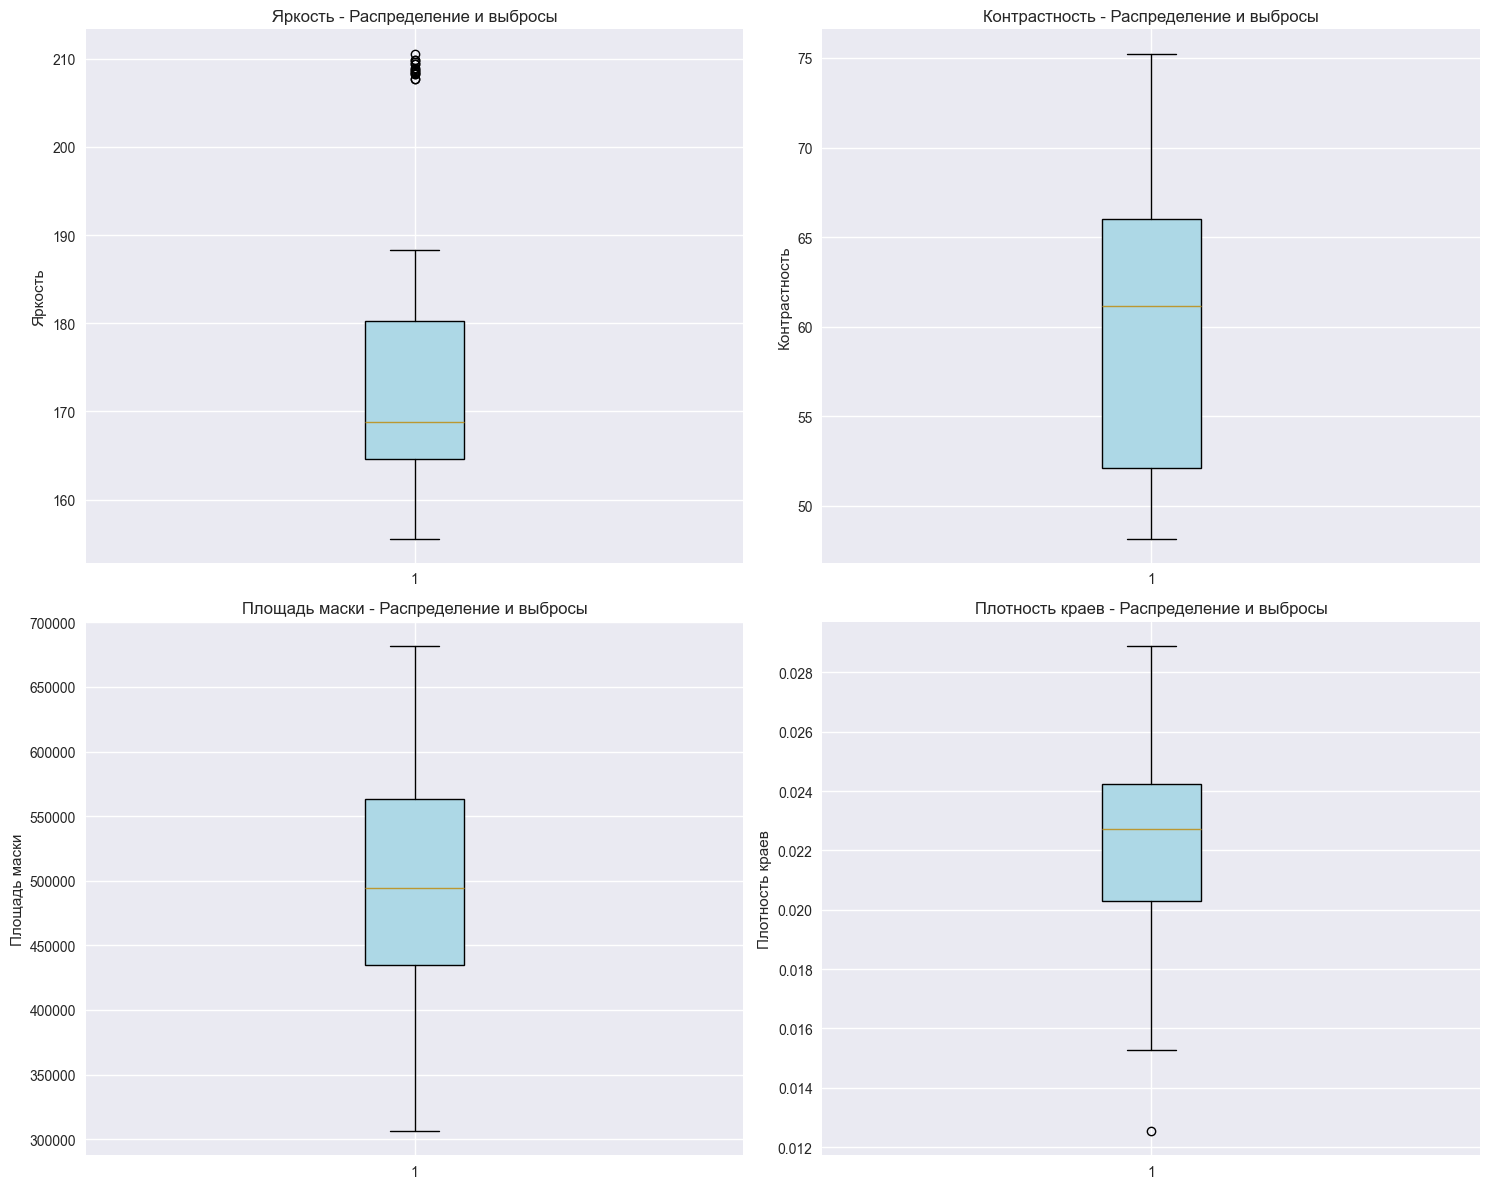

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics_list = ['brightness', 'contrast', 'mask_area', 'edge_density']
titles = ['Яркость', 'Контрастность', 'Площадь маски', 'Плотность краев']

for i, (metric, title) in enumerate(zip(metrics_list, titles)):
    row, col = divmod(i, 2)
    data = all_metrics[metric]

    if len(data) > 0:
        bp = axes[row, col].boxplot(data, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        axes[row, col].set_title(f'{title} - Распределение и выбросы')
        axes[row, col].set_ylabel(title)

plt.tight_layout()
plt.show()

In [27]:
for metric_name, result in outlier_results.items():
    outliers = result['outliers']
    print(f"\n{metric_name.upper()}:")
    print(f"  Найдено выбросов: {len(outliers)}")
    if len(outliers) > 0:
        outlier_values = [val for _, val in outliers[:5]]
        print(f"  Примеры значений выбросов: {[round(val, 2) for val in outlier_values]}")


BRIGHTNESS:
  Найдено выбросов: 16
  Примеры значений выбросов: [np.float64(210.59), np.float64(209.9), np.float64(208.6), np.float64(208.97), np.float64(208.5)]

CONTRAST:
  Найдено выбросов: 0

MASK_AREA:
  Найдено выбросов: 0

EDGE_DENSITY:
  Найдено выбросов: 1
  Примеры значений выбросов: [np.float64(0.01)]


## Сравнительный анализ сегментированных и несегментированных областей

In [28]:
car_brightness = []
background_brightness = []
car_texture = []
background_texture = []

sample_count = min(20, len(dataset))
for i in range(0, len(dataset), max(1, len(dataset)//sample_count)):
    try:
        image, mask = dataset[i]
        image_np = image.permute(1, 2, 0).numpy().astype(np.uint8)
        mask_np = mask.squeeze().numpy()

        binary_mask = mask_np > 0.5

        car_pixels = image_np[binary_mask]
        background_pixels = image_np[~binary_mask]

        if len(car_pixels) > 0 and len(background_pixels) > 0:
            car_brightness.append(np.mean(car_pixels))
            background_brightness.append(np.mean(background_pixels))

            car_gray = np.mean(car_pixels.reshape(-1, 3), axis=1)
            bg_gray = np.mean(background_pixels.reshape(-1, 3), axis=1)

            car_gradient = np.std(car_gray) if len(car_gray) > 1 else 0
            bg_gradient = np.std(bg_gray) if len(bg_gray) > 1 else 0

            car_texture.append(car_gradient)
            background_texture.append(bg_gradient)

    except Exception as e:
        continue

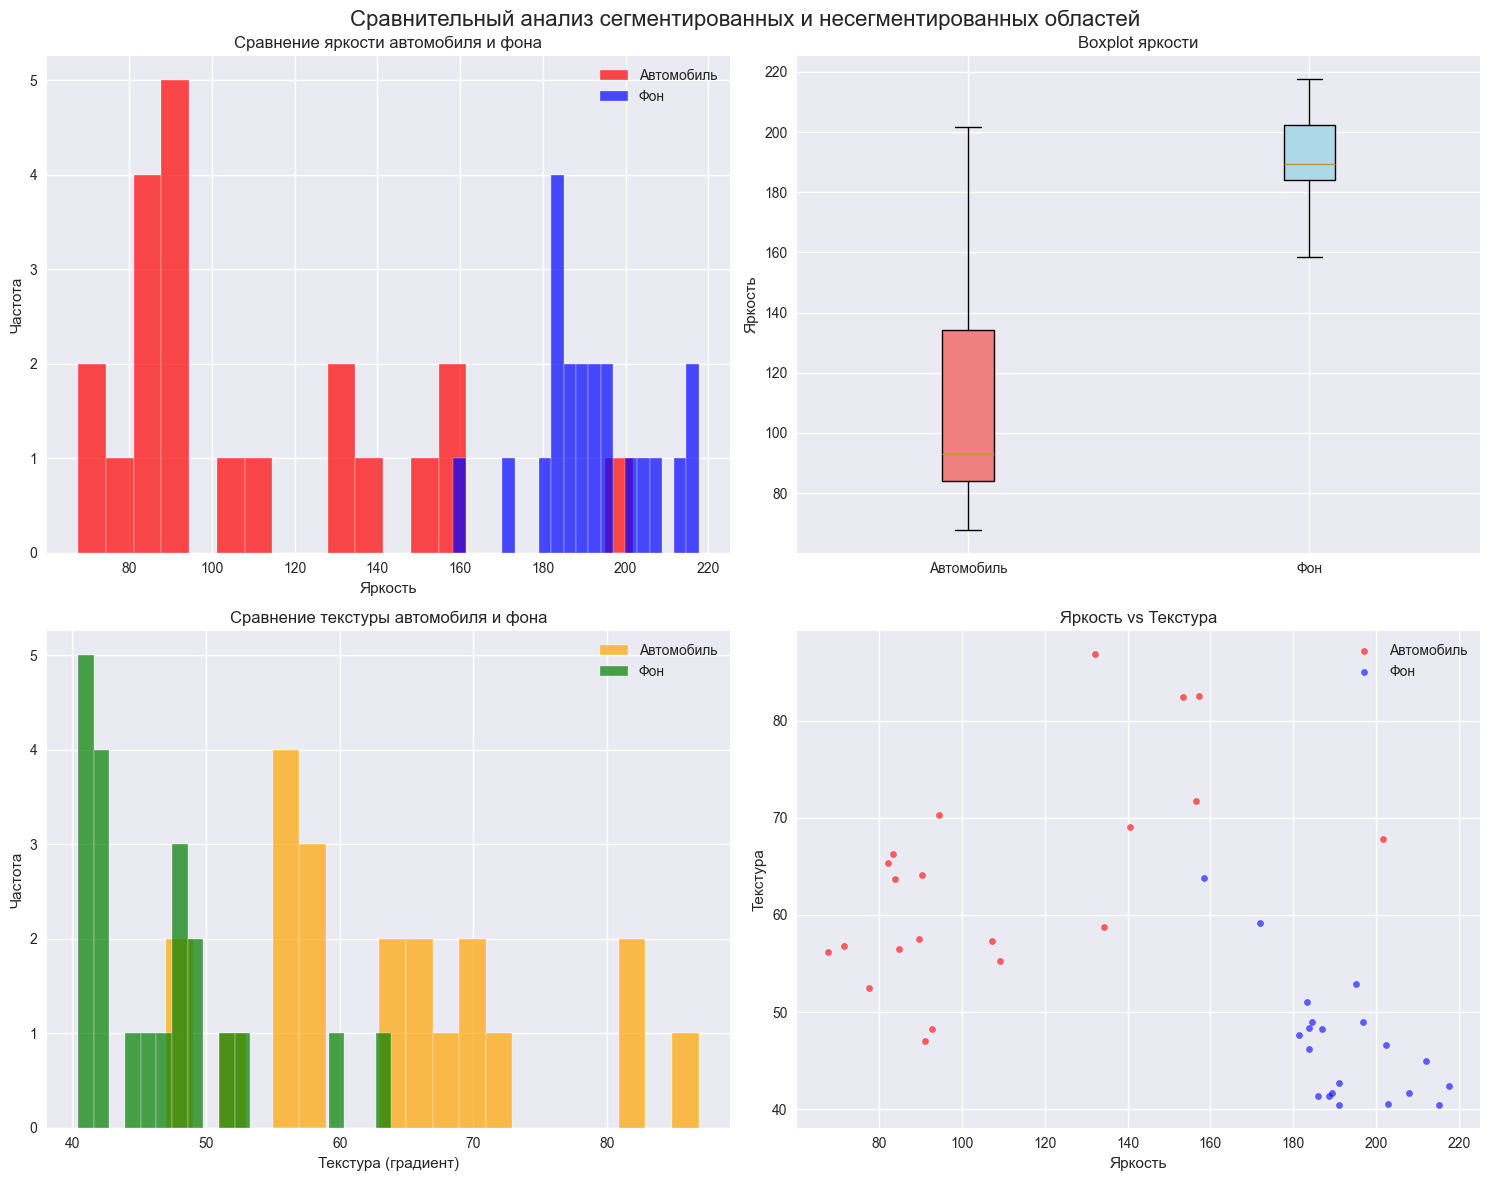

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].hist(car_brightness, bins=20, alpha=0.7, color='red', label='Автомобиль')
axes[0, 0].hist(background_brightness, bins=20, alpha=0.7, color='blue', label='Фон')
axes[0, 0].set_title('Сравнение яркости автомобиля и фона')
axes[0, 0].set_xlabel('Яркость')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

bp_data = [car_brightness, background_brightness]
bp = axes[0, 1].boxplot(bp_data, labels=['Автомобиль', 'Фон'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
axes[0, 1].set_title('Boxplot яркости')
axes[0, 1].set_ylabel('Яркость')

axes[1, 0].hist(car_texture, bins=20, alpha=0.7, color='orange', label='Автомобиль')
axes[1, 0].hist(background_texture, bins=20, alpha=0.7, color='green', label='Фон')
axes[1, 0].set_title('Сравнение текстуры автомобиля и фона')
axes[1, 0].set_xlabel('Текстура (градиент)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()

axes[1, 1].scatter(car_brightness, car_texture, alpha=0.6, color='red', label='Автомобиль', s=20)
axes[1, 1].scatter(background_brightness, background_texture, alpha=0.6, color='blue', label='Фон', s=20)
axes[1, 1].set_title('Яркость vs Текстура')
axes[1, 1].set_xlabel('Яркость')
axes[1, 1].set_ylabel('Текстура')
axes[1, 1].legend()

plt.suptitle('Сравнительный анализ сегментированных и несегментированных областей', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
if len(car_brightness) > 0 and len(background_brightness) > 0:
    print("СТАТИСТИКА СРАВНЕНИЯ:")
    print(f"Средняя яркость автомобиля: {np.mean(car_brightness):.2f}")
    print(f"Средняя яркость фона: {np.mean(background_brightness):.2f}")
    print(f"Разница в яркости: {abs(np.mean(car_brightness) - np.mean(background_brightness)):.2f}")

    print(f"\nСредняя текстура автомобиля: {np.mean(car_texture):.2f}")
    print(f"Средняя текстура фона: {np.mean(background_texture):.2f}")
    print(f"Разница в текстуре: {abs(np.mean(car_texture) - np.mean(background_texture)):.2f}")

СТАТИСТИКА СРАВНЕНИЯ:
Средняя яркость автомобиля: 109.56
Средняя яркость фона: 191.96
Разница в яркости: 82.40

Средняя текстура автомобиля: 63.64
Средняя текстура фона: 46.65
Разница в текстуре: 17.00
